In [1]:
import math
from copy import copy, deepcopy
import numpy as np
from pandas import DataFrame
import matplotlib.pyplot as plt

Define system parameters for the single lane. We collect all local current local variables in `param` to easily pass these on as keyword arguments.

In [2]:
omega = 0.5
L, W, D = 0.75, 0.25, 5
p0 = -D + W
params = copy(locals())

Define auxiliary functions to describe acceleration and deceleration parts of optimal trajectories. Furthermore, calculate the stationary lane capacity and the point from which vehicles must decelerate to stop at the first waiting position.

In [3]:
def acc(t, v0=0): return v0*t + omega*t*t/2
def dec(t, v0=1): return v0*t - omega*t*t/2
capacity = math.floor((D - W - 2 * acc(1/omega)) / L)
pd = -2 * acc(1/omega) - (capacity - 1) * L

### Direct transcription

In [4]:
from amplpy import AMPL

def trajectory_direct(T=100, p0=-10, v0=1, prev=None, amax=0.5, vmax=1, dt=0.01, **kwargs):
    """Solve the MotionSynthesize problem with direct transcription to a linear program.
    A part of the predecessor's trajectory can be specified by `prev`, which is a list
    of positions, starting from the first time epoch of this problem.

    T = number of discrete time steps
    (p0, v0) = initial (position, velocity)
    prev = previous trajectory, as list of positions at discrete time epochs from start
    vmax, amax = maximum speed and acceleration
    dt = discrete time step size
    """
    model = r"""
    param T; # number of discrete time epochs
    param dt; # discrete time epoch size
    set Ts = 1..T; # epoch indices

    param vmax; # maximum velocity
    param amax; # maximum acceleration
    param p0; # initial position, must be < 0
    param v0; # initial velocity, must be 0 <= v0 <= 1

    # state and control variables
    var x {Ts}; # position
    var v {Ts}; # velocity
    var u {Ts}; # control (acceleration)

    maximize objective: sum {t in Ts} x[t];

    subject to x_start: x[1] = p0;
    subject to v_start: v[1] = v0;
    #subject to x_end: x[T] = 0; # this is too restrictive numerically
    subject to x_end_1 {t in 1..T-1}: x[t] <= 0; # alternative
    subject to x_end_2:               x[T] >= 0; # alternative
    subject to v_end: v[T] >= vmax - 0.01; # with a little tolerance

    subject to v_bounds {t in Ts}: 0 <= v[t] <= vmax;
    subject to u_bounds {t in Ts}: -amax <= u[t] <= amax;

    # forward Euler
    subject to integrate_x {t in 1..T-1}: x[t+1] = x[t] + dt*v[t];
    subject to integrate_v {t in 1..T-1}: v[t+1] = v[t] + dt*u[t];
    """

    # add lead constraint (vehicle ahead)
    if prev is not None:
        model += r"""
        param Y; # number of time steps in lead vehicle trajectory
        set Ys = 1..Y;
        param y {Ys}; # position of lead vehicle
        subject to lead {t in Ys}: y[t] >= x[t];"""

    ampl = AMPL()
    ampl.eval(model)

    ampl.param["dt"] = dt
    ampl.param["T"] = T
    ampl.param["p0"] = p0
    ampl.param["v0"] = v0
    ampl.param["vmax"] = vmax
    ampl.param["amax"] = amax

    if prev is not None:
        ampl.param["Y"] = len(prev)
        ampl.param["y"] = prev

    ampl.option['presolve_eps'] = 1e-12
    ampl.solve(solver="gurobi");
    assert ampl.solve_result == "solved"
    return ampl.get_variable("x").to_pandas().T.values.tolist()[0]


from IPython.utils import io

def lane_direct(entry_times, exit_times, L=0.75, omega=0.5, dt=0.1, **kwargs):
    trajectories, prev = [], None
    for entry, exit in zip(entry_times, exit_times):
        yv = int(math.ceil(entry / dt)) # discretize start time
        yw = int(math.ceil(exit / dt))  # discretize end time
        if prev is not None:
            # extract the relevant steps from prev trajectory
            prev = prev[prev['t'] >= yv * dt]['x'].to_numpy() - L
        with io.capture_output() as captured:
            x = trajectory_direct(T=yw - yv + 1, p0=p0, prev=prev, amax=omega, dt=dt)
        xd = DataFrame.from_dict({'x': x, 't': dt * np.array(range(yv, yw + 1))})
        trajectories.append(xd)
        prev = xd.copy()
    return trajectories


def plot_lane(trajectories, axes=True, h_rules=False, ax=None, **kwargs):
    if ax is None:
        _, ax = plt.subplots()
    ax.set_ylabel(r'$x_1$')

    if h_rules:
        style = { 'color': 'lightgrey', 'linestyle': '--', 'lw': 1 }
        for i in range(capacity): # waiting positions
            plt.axhline(y=-acc(1/omega) - i * L, **style)
        plt.axhline(y=pd,   **style) # dec for p_1
        plt.axhline(y=p0+L, **style) # earliest dec
        plt.axhline(y=p0-W, **style) # start of v
        plt.axhline(y=p0,   **style) # start of lane
        plt.axhline(y=0,    **style) # start of w
    
    for tr in trajectories:
        style = { 'legend': False, 'color': 'k', 'lw': 1, **kwargs }
        tr.plot(x='t', y='x', ax=ax, **style)

    if not axes:
        ax.axis('off')
    
    return ax

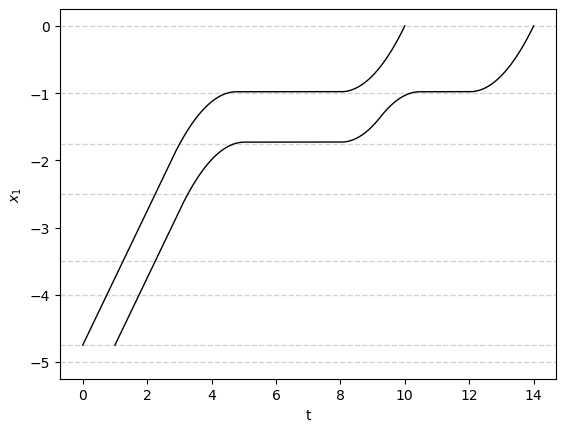

In [5]:
res = lane_direct([0, 1], [10, 14], dt=0.001, **params)
plot_lane(res, axes=True, h_rules=True);

### Explicit solution

Data class for specifying trajectories by their junction times, with an auxiliary `trace()` function that evaluates the trajectory on a regular time grid, to support plotting.

In [6]:
class Trajectory:
    def __init__(self, p0, tf, td, ts, ta, v0=1):
        self.p0 = p0
        self.v0 = v0
        self.t = { 'f': tf, 'd': td, 's': ts, 'a': ta }
        #self.trace()

    def shift(self, dt, dx):
        self.p0 += dx
        for k in self.t:
            for i in range(len(self.t[k])):
                self.t[k][i] += dt
        if hasattr(self, 'tau1'): self.tau1 += dt
        if hasattr(self, 'tau2'): self.tau2 += dt
        self.trace()

    def trace(self, dt=0.005, **kwargs):
        """Given the junction times, we compute the trajectory along
        time steps of fixed size `dt` to enable plotting."""
        tf, ts, ta, td = self.t['f'], self.t['s'], self.t['a'], self.t['d']

        tt, xx = np.arange(tf[0], tf[-1], dt), []
        i, xf_next, vd_next = -1, self.p0, self.v0
        self.xa, self.va = [], []
        for t in tt:
            while t >= tf[i + 1]:
                if (i := i + 1) >= len(ts):
                    # t == tf[-1], so we add the end position manually
                    print(len(tt), len(xx))
                    if len(tt) != len(xx):
                        xx.append(xf_next)
                    print('debug HIT')
                    self.tr = DataFrame({'t': tt, 'x': xx})
                    return
    
                xf = xf_next
                vd = vd_next
                xd = xf + (td[i] - tf[i])
                xa = xd + dec(ts[i] - td[i], v0=vd)
                va = vd - (ts[i] - td[i]) * omega
                xf_next = xa + acc(tf[i+1] - ta[i], v0=va)
                vd_next = va + (tf[i+1] - ta[i]) * omega

                self.xa.append(xa)
                self.va.append(va)

            if tf[i] <= t < td[i]:
                x = xf + (t - tf[i])
            elif td[i] <= t < ts[i]:
                x = xd + dec(t - td[i], v0=vd)
            elif ts[i] <= t < ta[i]:
                x = xa
            elif ta[i] <= t < tf[i+1]:
                x = xa + acc(t - ta[i], v0=va)
    
            xx.append(x)
    
        self.tr = DataFrame({'t': tt, 'x': xx})

    def plot(self, plot_tau=False, **kwargs):
        self.trace(**kwargs)
        [kwargs.pop(key, None) for key in ['x', 'y', 'dt']]
        ax = kwargs.pop('ax', plt.gca())
        style = { 'legend': False, 'color': 'k', 'lw': 1, **kwargs }
        self.tr.plot(x='t', y='x', ax=ax, **style)
        if plot_tau and hasattr(self, 'tau1') and hasattr(self, 'tau2'):
            plt.gca().axvline(x=self.tau1, linestyle='--', color='green', lw=1)
            plt.gca().axvline(x=self.tau2, linestyle='--', color='red', lw=1)

First, consider the case when the lead vehicle can be ignored, which we call the "single vehicle variant" of the problem.

In [7]:
def single_vehicle(t0, p0, omega=0.5):
    d = min(1/omega, math.sqrt((p0-t0)/omega))
    td = omega*d*d - 2*d - p0
    return Trajectory(p0, [t0, 0], [t0 + td], [t0 + td + d], [-d])

Given `t0` and `p0` for the current vehicle and the lead trajectory (characterized by junction times `td`, `ts`, `ta`, `td` and it's positions `xa` and velocities `va` at times `ta`), compute the junction times for the current vehicle.

In [8]:
def trajectory_explicit(t0=-10, p0=-10, tr=None, omega=0.5, **kwargs):
    tf, td, ts, ta, xa, va = tr.t['f'], tr.t['d'], tr.t['s'], tr.t['a'], tr.xa, tr.va
    
    # check if lead constraint can be ignored
    xfn = xa[-1] + acc(tf[-1] - ta[-1], v0=va[-1])
    if t0 >= tf[-1] - xfn + p0:
        return single_vehicle(t0, p0, omega=omega)
    
    # times for the next trajectory
    tfn, tsn, tan, tdn = [t0], [], [], []

    # compute entry time
    tau1 = None
    for i in range(len(ts)):
        tau11 = t0 - p0 + 1/(2*omega) + xa[i]
        if ts[i] <= tau11 <= ta[i]:
            tau1 = tau11
            # hit during standing
            tdn.append(tau11 - 1/omega)
            tsn.append(tau11)
            # follow full boundary
            tan.extend(ta[i:])
            tfn.extend(tf[i+1:])
            tdn.extend(td[i+1:])
            tsn.extend(ts[i+1:])
            break
        D = 2*(-2*xa[i]*omega + va[i]*va[i] - 2*va[i] +2*ta[i]*omega + 2*omega*p0 - 2*omega*t0 + 1)
        if D >= 0:
            tau12 = ta[i] - va[i]/omega + 1/omega - math.sqrt(D) / (2*omega)
        if D >= 0 and ta[i] <= tau12 <= tf[i+1]:
            tau1 = tau12            
            # hit during acceleration
            tdn.append(2*tau12 - ta[i] + (va[i]-1)/omega)
            tsn.append(tau12)
            tan.append(tau12)
            # follow full boundary
            tan.extend(ta[i+1:])
            tfn.extend(tf[i+1:])
            tdn.extend(td[i+1:])
            tsn.extend(ts[i+1:])
            break
    
    if tau1 is None:
        print('entry not feasible')
        return None
    
    # compute exit time
    tau2 = None
    n = len(ta) - 1
    for i in range(n, -1, -1):
        # N.B., we write tfi to denote t_{f, i+1}
        tfi, tai, vai = tf[i+1], ta[i], va[i]
        xfi = xa[-1] + acc(tfi - tai, v0=vai)
        tau21 = -xfi + tfi - 1/omega
        tau22 = -math.sqrt(4*(xfi - tfi) / omega) if xfi >= tfi else None
        if tfi <= tau21 <= tfi + L and tau21 < -2/omega:
            tau2, ts, ta = tau21, tau21 + 1/omega, -1/omega
            segment = 'full'
            break
        if tau22 is not None and tfi <= tau22 <= tfi + L and tau22 >= -2/omega:
            tau2, ts, ta = tau22, tau22 / 2, tau22 / 2
            segment = 'full'
            break
    
        xai, vai = xa[i], va[i]
        tau23 = (math.sqrt(-4*omega*xai + 2*vai*vai - 2) -2*vai +2*omega*tai)/(2*omega) if -4*omega*xai + 2*vai*vai - 2 >= 0 else None
        denumerator = -4*vai*omega + 4*tai*omega*omega + 4*omega
        tau24 = (4*xai*omega + vai*vai - 6*vai*tai*omega - 2*vai + 3*tai*tai*omega*omega + 2*tai*omega + 1) \
                    / denumerator if denumerator != 0 else None
        if tau23 is not None and tai <= tau23 <= tfi and 2*tau23 + (1 + vai)/omega - tai < 0:
            d = vai/omega + tau23 - tai
            tau2, ts, ta = tau23, tau23 + d, -1/omega
            segment = 'acc'
            break
        if tau24 is not None and tai <= tau24 <= tfi and 2*tau23 + (1 + vai)/omega - tai >= 0:
            d = (vai - omega*tai - 1)/(2*omega)
            tau2, ts, ta = tau24, tau24 + d, tau24 + d
            segment = 'acc'
            break

    if tau2 is None or tau1 > tau2:
        print('exit not feasible')
        return None

    # replace with the trajectory after exit
    tfn = [t for t in tfn if t < tau2]
    if segment == 'acc':
        tfn = tfn + [tau2, 0]
    elif segment == 'full':
        tfn = tfn + [0]
    tsn = [t for t in tsn if t < tau2] + [ts]
    tan = [t for t in tan if t < tau2] + [ta]
    tdn = [t for t in tdn if t < tau2] + [tau2]

    tr = Trajectory(p0, tfn, tdn, tsn, tan)
    tr.tau1, tr.tau2 = tau1, tau2
    return tr

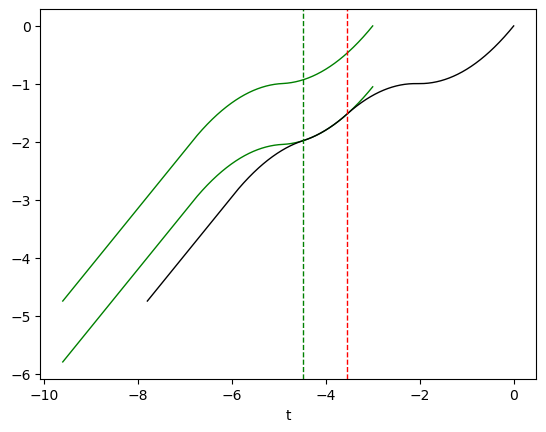

In [9]:
_, ax = plt.subplots()
tr1 = single_vehicle(-6.6, p0)
tr1.shift(-3, 0)
tr1.plot(ax=ax, color='g') # plot the lead constraint
tr1.shift(0, -1.4*L)
tr1.plot(ax=ax, color='g') # plot the lead constraint

tr2 = trajectory_explicit(t0=-7.8, p0=p0, tr=tr1)
tr2.plot(plot_tau=True, ax=ax); # show entry and exit times

Compute trajectories for a bunch of vehicles on the same lane.

In [10]:
def lane_explicit(entry_times, exit_times, L=0.75, omega=0.5, **kwargs):
    assert len(entry_times) == len(exit_times)
    trs = []

    tr = single_vehicle(entry_times[0] - exit_times[0], p0, omega=omega)
    tr1 = deepcopy(tr)
    tr1.shift(exit_times[0], 0)
    trs.append(tr1)

    for i in range(1, len(entry_times)):
        tr.shift(exit_times[i-1] - exit_times[i], -L)
        tr = trajectory_explicit(t0=entry_times[i] - exit_times[i], tr=tr, p0=p0, omega=omega)
        tr1 = deepcopy(tr)
        tr1.shift(exit_times[i], 0)
        trs.append(tr1)

    return trs

### Plots

#### Some example

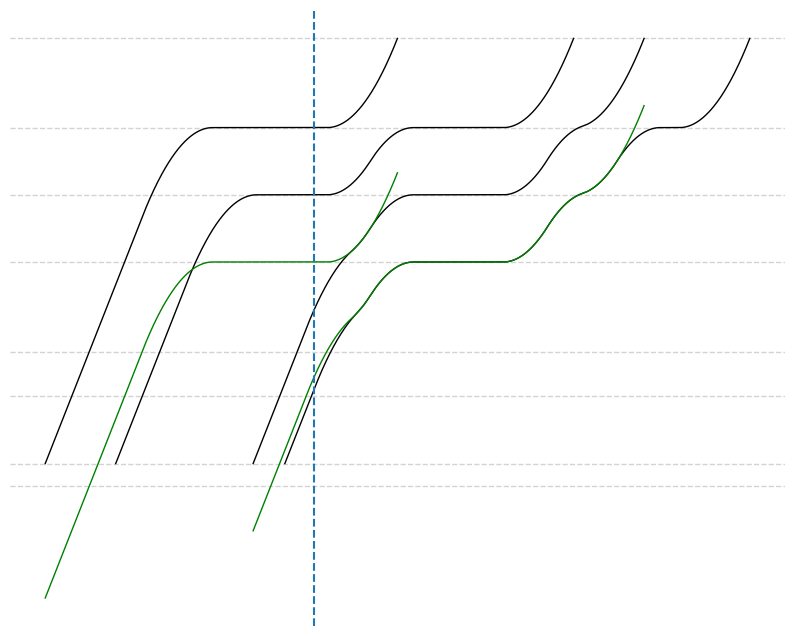

In [11]:
plt.subplots(figsize=(10,8))

entry_times, exit_times = [0, 2, 5.9, 6.8], [10, 15, 17, 20]
trs = lane_explicit(entry_times, exit_times, L=L, omega=omega)
plot_lane(trs, axes=False, color='k', h_rules=True, ax=plt.gca());

trs[0].shift(0, -2*L)
trs[0].plot(color='green')

trs[-2].shift(0, -L)
trs[-2].plot(color='green')

# plot deceleration of last vehicle
x = trs[-1].t['d'][0]
plt.gca().axvline(x=x, linestyle='--');

# trs_direct = lane_direct(entry_times, exit_times, dt=0.01, L=L, omega=omega)
# plot_lane(trs_direct, color='green', axes=True, ax=plt.gca());

#### Buffer constraint illustration

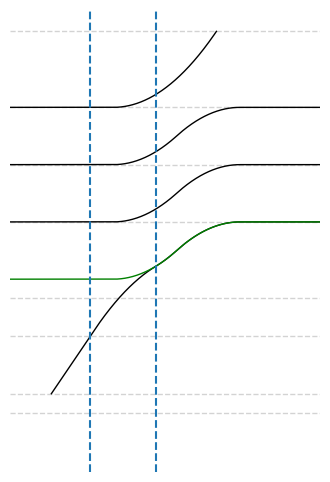

In [12]:
plt.subplots(figsize=(4,6))
entry_times, exit_times = [0, L, 2*L, 6.8], [10, 15, 15 + 2*L, 15 + 5*L]
trs = lane_explicit(entry_times, exit_times, L=L, omega=omega)
plot_lane(trs, axes=False, color='k', h_rules=True, ax=plt.gca());
trs[-2].shift(0, -L)
trs[-2].plot(color='green')
plt.gca().axvline(x=6.8+L, linestyle='--')
plt.gca().axvline(x=trs[-1].tau1, linestyle='--')
plt.gca().set_xlim([6, 12]);
plt.savefig('example1.pdf')

#### Trajectory joining example

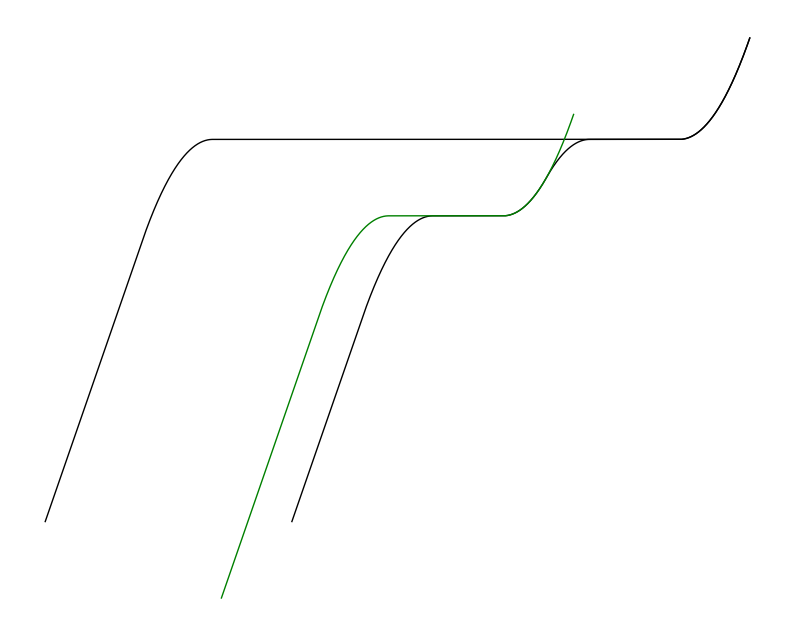

In [13]:
plt.subplots(figsize=(10,8))

entry_times, exit_times = [0, 2], [10, 15]
trs = lane_explicit(entry_times, exit_times, L=L, omega=omega)
gamma2 = lane_explicit([-5], [15], L=L, omega=omega)

#plot_lane(trs, axes=True, color='k', h_rules=True, ax=plt.gca());

trs[1].plot(ax=plt.gca())

plot_lane(gamma2, axes=False, color='k', ax=plt.gca());

trs[0].shift(0, -L)
trs[0].plot(color='green')

plt.savefig('figures/rough/curvejoining.pdf')

### Exit lead boundary

#### Case "1"

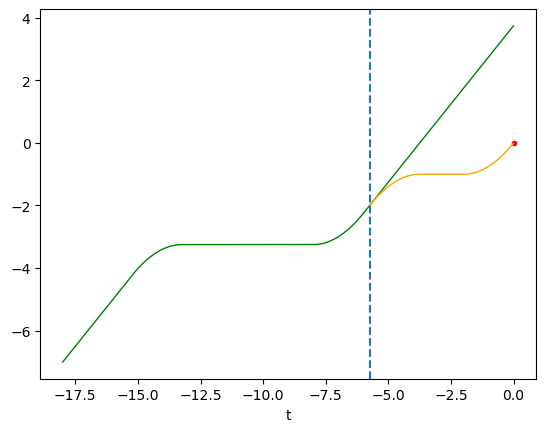

In [398]:
_, ax = plt.subplots()
ax.plot(0, 0, 'r.')

tr = single_vehicle(-12, p0)

# for this example, we fix the start of the last acceleration of the lead trajectory
tan = -8
tr.shift(tan + 1/omega, -3*L)
tr.plot(ax=ax, color='green')

tf, ta, va = tr.t['f'][-1], tr.t['a'][-1], tr.va[-1]
xf = tr.xa[-1] + acc(tf - ta, v0=va)

# plot the implicit boundary
tt = np.arange(tf, 0, 0.01)
plt.plot(tt, tt - tf + xf, color='green', lw=1)

tau = -xf + tf - 1/omega
p0n = -1/omega

tr = Trajectory(p0n, [tau, 0], [tau], [tau+1/omega], [-1/omega], v0=1)
tr.plot(color='orange', ax=ax)
ax.axvline(x=tau, linestyle='--');

#### Case "2"

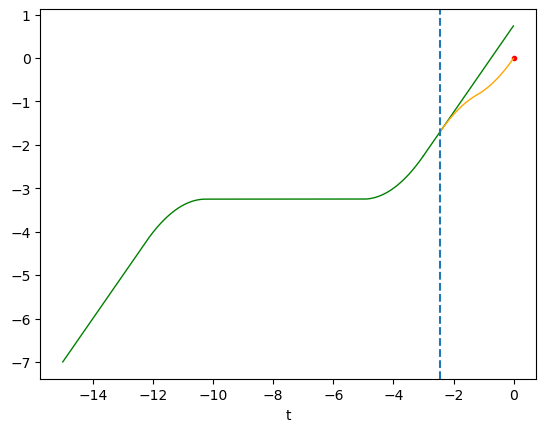

In [399]:
_, ax = plt.subplots()
ax.plot(0, 0, 'r.')

tr = single_vehicle(-12, p0)

# for this example, we fix the start of the last acceleration of the lead trajectory
tan = -5
tr.shift(tan + 1/omega, -3*L)
tr.plot(ax=ax, color='green')

tf, ta, va = tr.t['f'][-1], tr.t['a'][-1], tr.va[-1]
xf = tr.xa[-1] + acc(tf - ta, v0=va)

# plot the implicit boundary
tt = np.arange(tf, 0, 0.01)
plt.plot(tt, tt - tf + xf, color='green', lw=1)

tau = -math.sqrt((4*xf - 4*tf) / omega)
p0n = -2*dec(-tau/2)

tr = Trajectory(p0n, [tau, 0], [tau], [tau/2], [tau/2], v0=1)
tr.plot(color='orange', ax=ax)
ax.axvline(x=tau, linestyle='--');

#### Case "3"

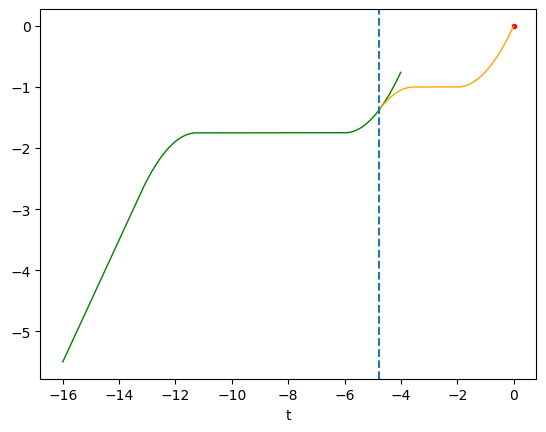

In [400]:
_, ax = plt.subplots()
ax.plot(0, 0, 'r.')

tr = single_vehicle(-12, p0)

# for this example, we fix the start of the last acceleration of the lead trajectory
tan = -6
tr.shift(tan + 1/omega, -L)
tr.plot(ax=ax, color='green')

xa, va, ta = tr.xa[-1], tr.va[-1], tr.t['a'][-1]
tau = (math.sqrt(-4*omega*xa + 2*va*va - 2) -2*va +2*omega*ta)/(2*omega)
d = va/omega + tau - ta
p0n = -acc(1/omega) - acc(d)

tr = Trajectory(p0n, [tau, 0], [tau], [tau+d], [-1/omega], v0=va + d*omega)
tr.plot(color='orange', ax=ax)
ax.axvline(x=tau, linestyle='--');

#### Case "4"

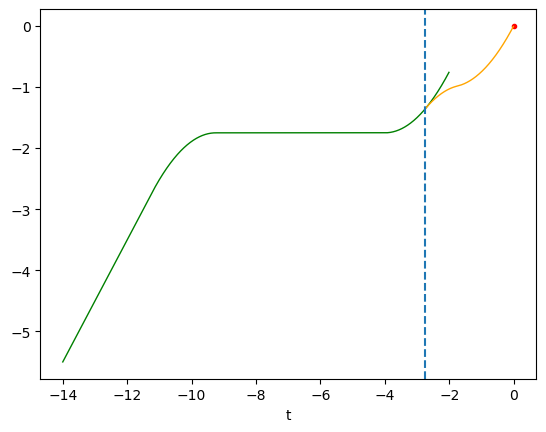

In [551]:
_, ax = plt.subplots()
ax.plot(0, 0, 'r.')

tr = single_vehicle(-12, p0)

# for this example, we fix the start of the last acceleration of the lead trajectory
tan = -4
tr.shift(tan + 1/omega, -L)
tr.plot(ax=ax, color='green')

xa, va, ta = tr.xa[-1], tr.va[-1], tr.t['a'][-1]
tau = (4*xa*omega + va*va - 6*va*ta*omega - 2*va + 3*ta*ta*omega*omega + 2*ta*omega + 1) / (-4*va*omega + 4*ta*omega*omega + 4*omega)
d = (va - omega*ta - 1)/(2*omega)
alpha = -tau - d
p0n = -dec(alpha) - acc(d, v0=1-alpha*omega)

tr = Trajectory(p0n, [tau, 0], [tau], [tau+d], [-alpha], v0=1 - alpha*omega + d*omega)
tr.plot(color='orange', ax=ax)
ax.axvline(x=tau, linestyle='--');